(404800, 27)


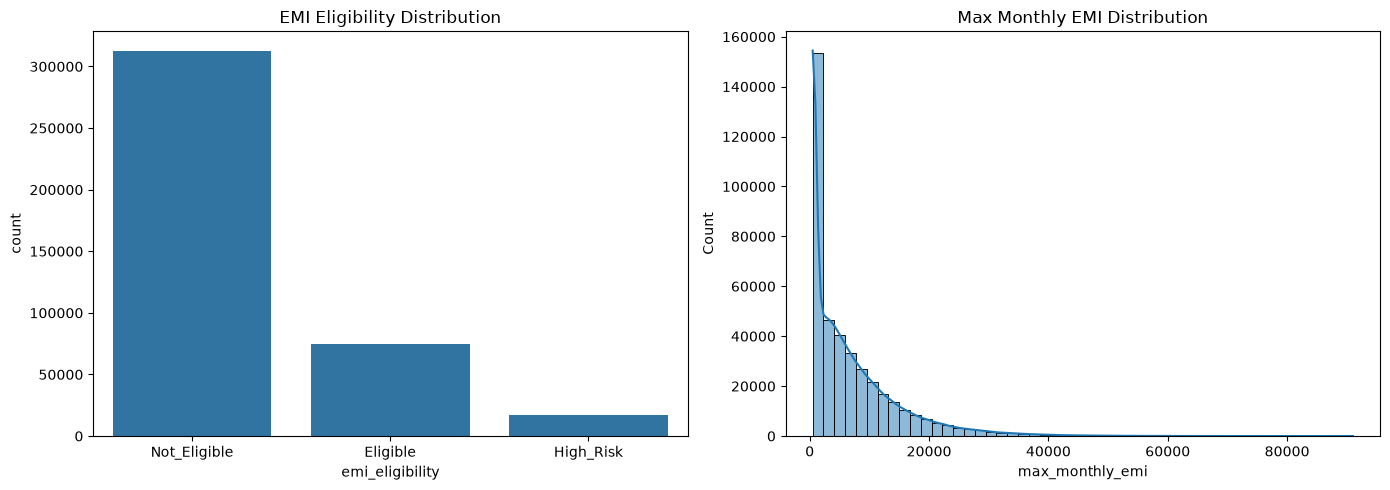

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv(r"D:\Code\Project\EMIPredict-AI\data\emi_cleaned.csv")
print(df.shape)
df.head()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='emi_eligibility', order=df['emi_eligibility'].value_counts().index, ax=axes[0])
axes[0].set_title('EMI Eligibility Distribution')

sns.histplot(df['max_monthly_emi'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Max Monthly EMI Distribution')

plt.tight_layout()
plt.show()

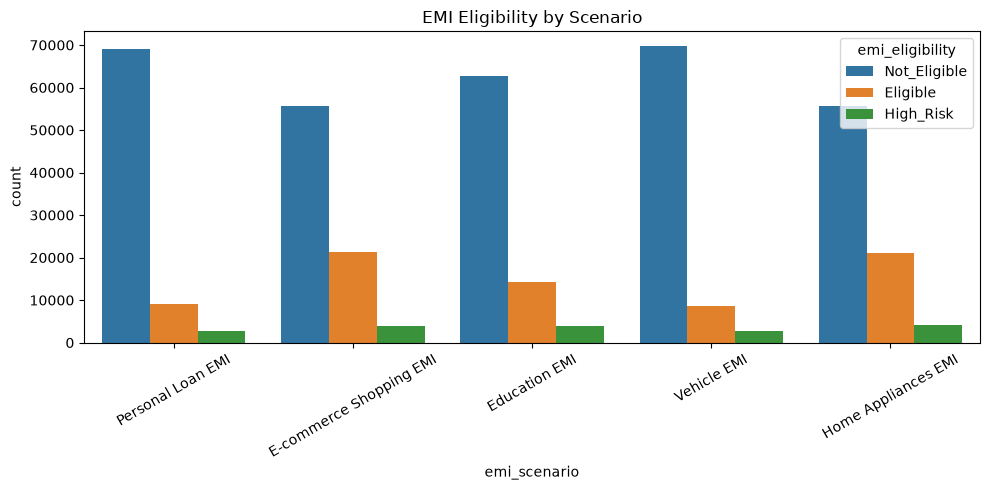

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='emi_scenario', hue='emi_eligibility')
plt.xticks(rotation=30)
plt.title('EMI Eligibility by Scenario')
plt.tight_layout()
plt.show()

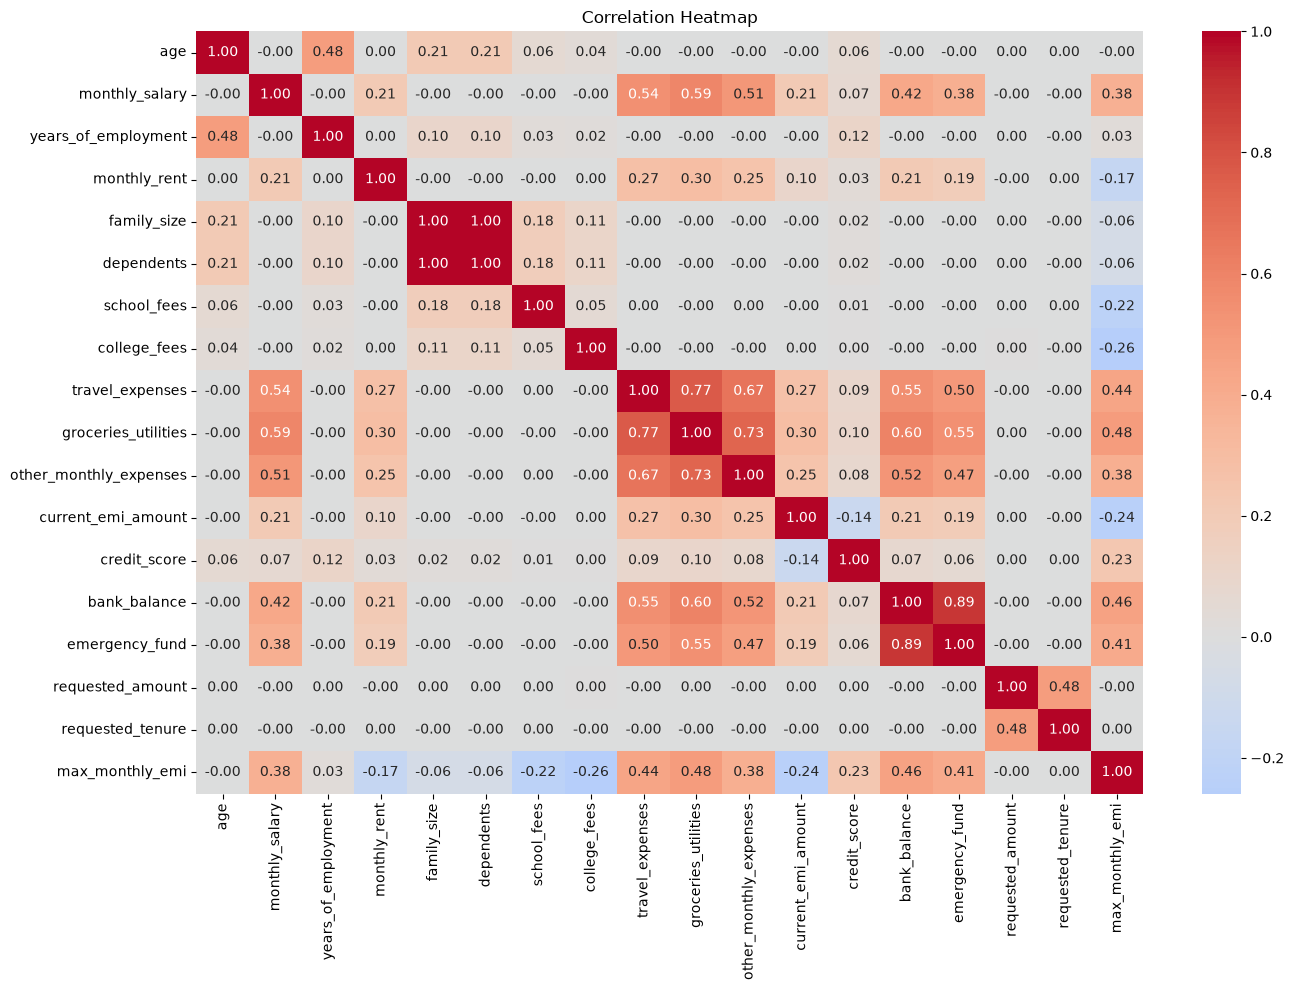

In [5]:
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

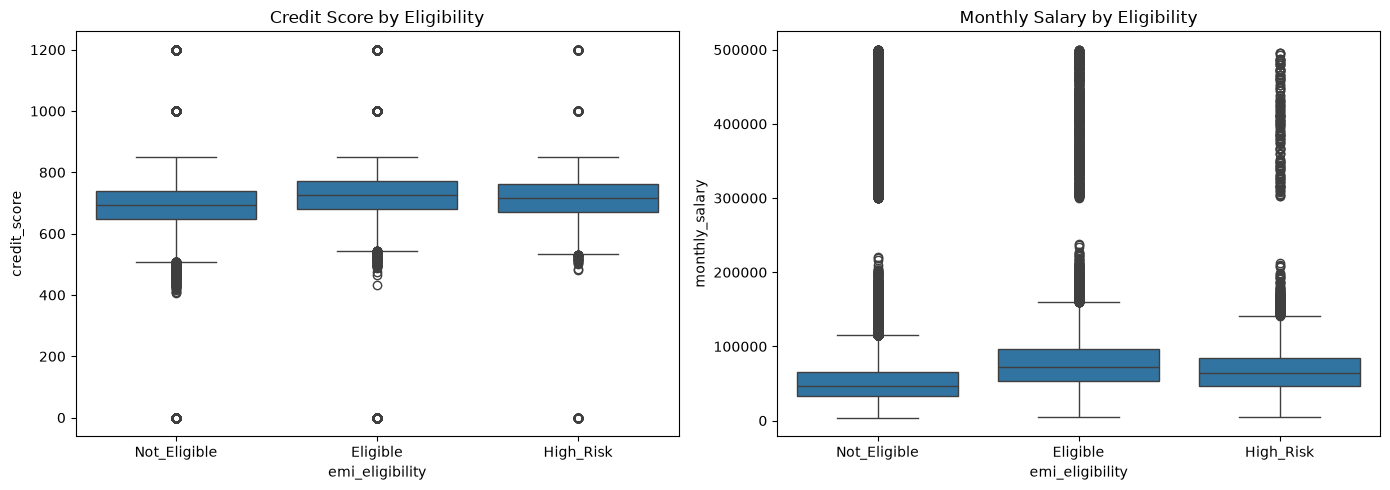

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='emi_eligibility', y='credit_score', ax=axes[0])
axes[0].set_title('Credit Score by Eligibility')

sns.boxplot(data=df, x='emi_eligibility', y='monthly_salary', ax=axes[1])
axes[1].set_title('Monthly Salary by Eligibility')

plt.tight_layout()
plt.show()

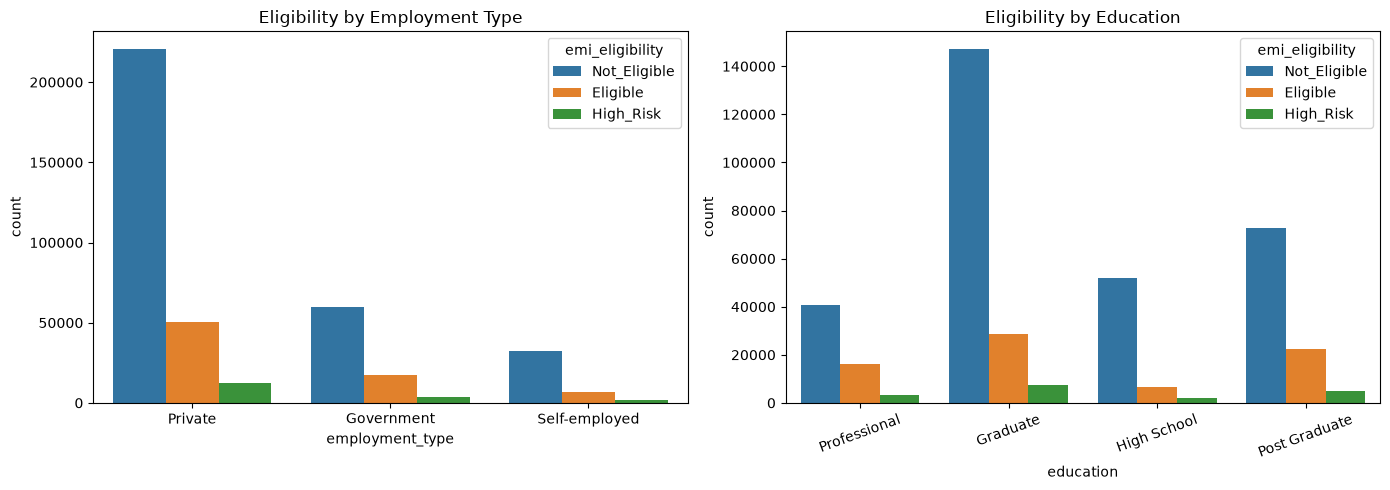

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='employment_type', hue='emi_eligibility', ax=axes[0])
axes[0].set_title('Eligibility by Employment Type')

sns.countplot(data=df, x='education', hue='emi_eligibility', ax=axes[1])
axes[1].set_title('Eligibility by Education')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [9]:
df['total_monthly_expense'] = (df['school_fees'] + df['college_fees'] + df['travel_expenses'] 
                                + df['groceries_utilities'] + df['other_monthly_expenses'] 
                                + df['monthly_rent'] + df['current_emi_amount'])

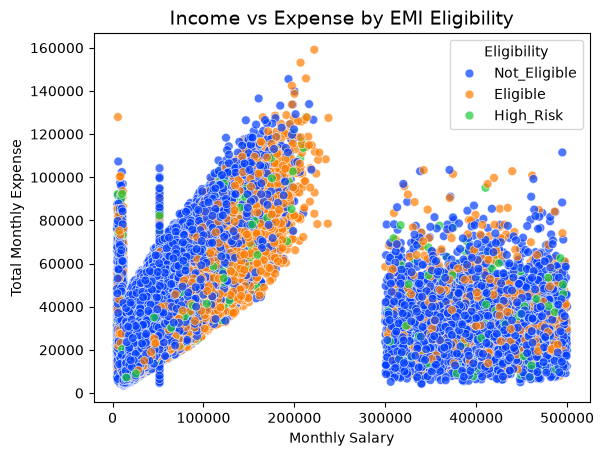

In [13]:
sns.scatterplot(
    x='monthly_salary',
    y='total_monthly_expense',
    hue='emi_eligibility',
    palette='bright',
    data=df,
    alpha=0.7,
    s=40
)
plt.title("Income vs Expense by EMI Eligibility", fontsize=14)
plt.xlabel("Monthly Salary")
plt.ylabel("Total Monthly Expense")
plt.legend(title='Eligibility')
plt.show()

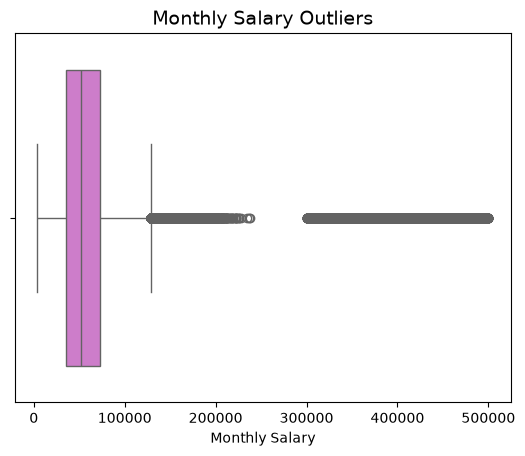

In [14]:
sns.boxplot(x=df['monthly_salary'], color='orchid')
plt.title("Monthly Salary Outliers", fontsize=14)
plt.xlabel("Monthly Salary")
plt.show()

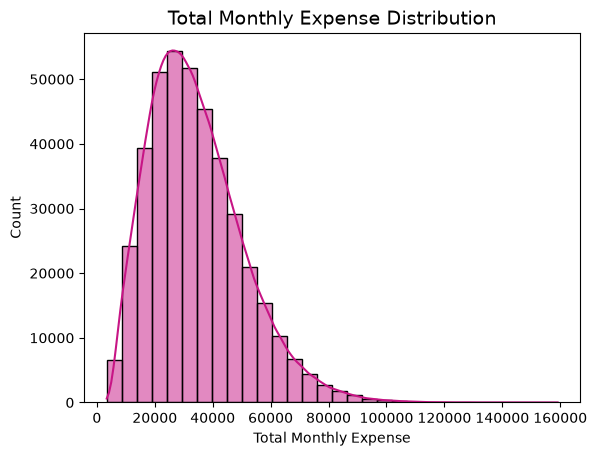

In [15]:
df['total_monthly_expense'] = (
    df['school_fees'] +
    df['college_fees'] +
    df['travel_expenses'] +
    df['groceries_utilities'] +
    df['other_monthly_expenses']
)
sns.histplot(df['total_monthly_expense'], bins=30, kde=True, color='mediumvioletred')
plt.title("Total Monthly Expense Distribution", fontsize=14)
plt.xlabel("Total Monthly Expense")
plt.show()

In [16]:
df['debt_to_income'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary']
df['expense_to_income'] = df['total_monthly_expense'] / df['monthly_salary']
df['affordability_ratio'] = df['monthly_salary'] - df['total_monthly_expense'] - df['current_emi_amount'] - df['monthly_rent']

df[['debt_to_income', 'expense_to_income', 'affordability_ratio']].describe()

,debt_to_income,expense_to_income,affordability_ratio
count,404800.000000,404800.000000,404800.000000
mean,0.191322,0.675865,14831.331744
std,0.245613,0.494049,37581.517747
min,0.000000,0.011144,-161883.000000
25%,0.000000,0.467401,400.000000
50%,0.183817,0.573551,10600.000000
75%,0.288660,0.751497,22400.000000
max,16.297906,21.744305,485540.000000


In [17]:
categorical_cols = ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 
                     'house_type', 'existing_loans', 'emi_scenario']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.shape

(404800, 41)

In [18]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size',
                     'dependents', 'total_monthly_expense', 'current_emi_amount', 'credit_score',
                     'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure',
                     'debt_to_income', 'expense_to_income', 'affordability_ratio']

scaler = StandardScaler()
df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])
df_encoded[numeric_features].describe()

,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,total_monthly_expense,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,debt_to_income,expense_to_income,affordability_ratio
count,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05,4.048000e+05
mean,-3.240974e-16,7.603931e-17,-1.649274e-16,3.159528e-17,1.348065e-16,-4.999075e-17,2.027013e-16,3.875688e-17,-6.406118e-16,1.404235e-18,6.305014e-17,-3.812497e-17,6.831602e-17,9.647092e-17,1.797420e-17,-2.625919e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-1.383973e+00,-1.282297e+00,-8.001279e-01,-6.709834e-01,-1.804714e+00,-1.804714e+00,-1.892849e+00,-6.458390e-01,-7.948866e+00,-1.289729e+00,-1.173521e+00,-1.045370e+00,-1.443396e+00,-7.789581e-01,-1.345458e+00,-4.702166e+00
25%,-7.390558e-01,-5.561055e-01,-6.849798e-01,-6.709834e-01,-8.746528e-01,-8.746528e-01,-7.413110e-01,-6.458390e-01,-5.314360e-01,-7.454552e-01,-7.151376e-01,-7.151206e-01,-7.804435e-01,-7.789581e-01,-4.219511e-01,-3.840012e-01
50%,-9.413904e-02,-1.795295e-01,-3.559852e-01,-6.709834e-01,5.540849e-02,5.540849e-02,-1.410412e-01,-6.458390e-01,1.620918e-03,-2.483667e-01,-2.789339e-01,-3.906654e-01,-2.279827e-01,-3.055349e-02,-2.070929e-01,-1.125909e-01
75%,9.807222e-01,3.079400e-01,3.020040e-01,5.566690e-01,9.854698e-01,9.854698e-01,5.878580e-01,4.913497e-01,5.346778e-01,4.830010e-01,4.135702e-01,3.567402e-01,6.007084e-01,3.963083e-01,1.530859e-01,2.013936e-01
max,2.163070e+00,1.017677e+01,5.039526e+00,8.594318e+00,1.915531e+00,1.915531e+00,7.644092e+00,7.357126e+00,5.661098e+00,8.098991e+00,9.794413e+00,3.271043e+00,3.031536e+00,6.557729e+01,4.264449e+01,1.252502e+01


In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['emi_eligibility', 'max_monthly_emi'])
y_class = df_encoded['emi_eligibility']
y_reg = df_encoded['max_monthly_emi']

X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

print(X_train.shape, X_test.shape)

(323840, 39) (80960, 39)


In [22]:
import mlflow

mlflow.set_tracking_uri("sqlite:///D:/Code/Project/EMIPredict-AI/mlruns/mlflow.db")
mlflow.set_experiment("EMIPredict_Classification")

2026/07/29 04:33:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/29 04:33:12 INFO mlflow.store.db.utils: Updating database tables
2026/07/29 04:33:16 INFO mlflow.tracking.fluent: Experiment with name 'EMIPredict_Classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:/Code/Project/EMIPredict-AI/notebooks/mlruns/1', creation_time=1785279796061, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785279796061, lifecycle_stage='active', name='EMIPredict_Classification', tags={}, trace_location=None, workspace='default'>

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

with mlflow.start_run(run_name="Logistic_Regression"):
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_class_train)
    
    y_pred = lr.predict(X_test)
    
    acc = accuracy_score(y_class_test, y_pred)
    prec = precision_score(y_class_test, y_pred, average='weighted')
    rec = recall_score(y_class_test, y_pred, average='weighted')
    f1 = f1_score(y_class_test, y_pred, average='weighted')
    
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(lr, "model")
    
    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")

d:\Code\Project\EMIPredict-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/07/29 04:36:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.8796, F1: 0.8591
